# PTQ 실습
## MNIST 와 MLP를 이용한 PTQ

### 환경 설정 및 재현성 설정

In [5]:
import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [6]:
SEED = 42

def seed_everything(seed=42, deterministic=True):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

        # 일부 연산이 deterministic 구현을 지원하지 않으면 에러가 날 수 있음
        torch.use_deterministic_algorithms(True)

        # CUDA matmul reproducibility 관련 권장 설정
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


seed_everything(SEED, deterministic=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("seed:", SEED)
print("device:", device)
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("cuda version:", torch.version.cuda)
    print("gpu:", torch.cuda.get_device_name(0))

seed: 42
device: cuda
torch version: 2.5.1+cu121
cuda available: True
cuda version: 12.1
gpu: NVIDIA RTX A6000


### MNIST 데이터셋 및 백본 준비

In [7]:
batch_size = 128

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=g,
)

print("train samples:", len(train_dataset))
print("test samples:", len(test_dataset))

class SimpleMLP(nn.Module):
    def __init__(self, hidden1=256, hidden2=128):
        super().__init__()

        self.fc1 = nn.Linear(28 * 28, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, hidden2)
        self.fc4 = nn.Linear(hidden2, hidden2)
        self.fc5 = nn.Linear(hidden2, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)
        x = F.relu(x)

        x = self.fc4(x)
        x = F.relu(x)

        x = self.fc5(x)

        return x
    
@torch.no_grad()
def evaluate_accuracy(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        pred = logits.argmax(dim=1)

        correct += (pred == y).sum().item()
        total += y.size(0)

    return correct / total * 100

train samples: 60000
test samples: 10000


In [8]:
model_fp = SimpleMLP(
    hidden1=256,
    hidden2=128,
).to(device).float()

optimizer = torch.optim.AdamW(model_fp.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 3

for epoch in range(epochs):
    model_fp.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model_fp(x)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    train_loss = total_loss / total
    train_acc = correct / total * 100

    test_acc = evaluate_accuracy(model_fp, test_loader, device)

    print(
        f"epoch {epoch+1:02d} | "
        f"train loss {train_loss:.4f} | "
        f"train acc {train_acc:.2f}% | "
        f"test acc {test_acc:.2f}%"
    )

epoch 01 | train loss 0.3259 | train acc 90.01% | test acc 95.51%
epoch 02 | train loss 0.1162 | train acc 96.40% | test acc 95.32%
epoch 03 | train loss 0.0829 | train acc 97.46% | test acc 96.78%


In [9]:
model_fp.eval()

fp32_acc = evaluate_accuracy(
    model=model_fp,
    loader=test_loader,
    device=device,
)

print(f"FP32 Test Accuracy: {fp32_acc:.2f}%")

FP32 Test Accuracy: 96.78%


### Quant-Dequant 준비

In [10]:
def symmetric_quant_dequant_tensor(x_fp32: torch.Tensor, num_bits: int):
    """
    Symmetric per-tensor quantize-dequantize.

    목적:
    - 실제 int kernel forward가 아님
    - bit별 weight-only PTQ 후 accuracy drop 확인

    Args:
        x_fp32: FP32 tensor
        num_bits: 2~8

    Returns:
        x_dequant: quantize 후 다시 FP32로 dequantize된 tensor
        x_int: quantized integer tensor
        scale: quantization scale
    """
    assert x_fp32.dtype == torch.float32
    assert 2 <= num_bits <= 8

    # signed symmetric quantization range
    # 예: 8bit -> [-127, 127], 4bit -> [-7, 7], 2bit -> [-1, 1]
    qmax = 2 ** (num_bits - 1) - 1
    qmin = -qmax

    max_abs = x_fp32.abs().max()

    if max_abs == 0:
        scale = torch.tensor(1.0, device=x_fp32.device, dtype=torch.float32)
        x_int = torch.zeros_like(x_fp32, dtype=torch.int32)
        x_dequant = torch.zeros_like(x_fp32)
        return x_dequant, x_int, scale

    scale = max_abs / qmax

    x_int = torch.round(x_fp32 / scale)
    x_int = torch.clamp(x_int, qmin, qmax).to(torch.int32)

    x_dequant = x_int.float() * scale

    return x_dequant, x_int, scale

In [11]:
def apply_weight_only_ptq(model_fp: nn.Module, num_bits: int):
    """
    FP32 모델을 deepcopy한 뒤,
    모든 nn.Linear layer의 weight만 quantize-dequantize 한다.

    bias는 FP32 그대로 유지한다.
    activation/input도 FP32 그대로 유지한다.
    """
    model_q = copy.deepcopy(model_fp).eval().float()

    layer_rows = []

    with torch.no_grad():
        for name, module in model_q.named_modules():
            if isinstance(module, nn.Linear):
                w_fp32 = module.weight.data.float()

                w_qdq, w_int, scale = symmetric_quant_dequant_tensor(
                    x_fp32=w_fp32,
                    num_bits=num_bits,
                )

                weight_error = w_qdq - w_fp32

                module.weight.data.copy_(w_qdq)

                layer_rows.append({
                    "bit": num_bits,
                    "layer": name,
                    "weight_shape": tuple(w_fp32.shape),
                    "scale": scale.item(),
                    "weight_error_mean": weight_error.mean().item(),
                    "weight_error_variance": weight_error.var(unbiased=False).item(),
                    "weight_error_std": weight_error.std(unbiased=False).item(),
                    "weight_mse": torch.mean(weight_error ** 2).item(),
                    "q_min": int(w_int.min().item()),
                    "q_max": int(w_int.max().item()),
                })

    return model_q, layer_rows

### 측정 및 시각화

In [12]:
bits_list = [8, 7, 6, 5, 4, 3, 2]

accuracy_rows = []
layer_rows_all = []
quantized_models = {}

for bit in bits_list:
    print(f"[run] {bit}-bit weight-only PTQ")

    model_q, layer_rows = apply_weight_only_ptq(
        model_fp=model_fp,
        num_bits=bit,
    )

    model_q = model_q.to(device).eval()

    ptq_acc = evaluate_accuracy(
        model=model_q,
        loader=test_loader,
        device=device,
    )

    accuracy_rows.append({
        "bit": bit,
        "fp32_accuracy": fp32_acc,
        "ptq_accuracy": ptq_acc,
        "accuracy_drop": fp32_acc - ptq_acc,
    })

    layer_rows_all.extend(layer_rows)
    quantized_models[bit] = model_q

accuracy_df = pd.DataFrame(accuracy_rows)
layer_error_df = pd.DataFrame(layer_rows_all)

display(accuracy_df)

[run] 8-bit weight-only PTQ
[run] 7-bit weight-only PTQ
[run] 6-bit weight-only PTQ
[run] 5-bit weight-only PTQ
[run] 4-bit weight-only PTQ
[run] 3-bit weight-only PTQ
[run] 2-bit weight-only PTQ


,bit,fp32_accuracy,ptq_accuracy,accuracy_drop
0,8,96.78,96.79,-0.01
1,7,96.78,96.89,-0.11
2,6,96.78,96.80,-0.02
3,5,96.78,96.62,0.16
4,4,96.78,96.54,0.24
5,3,96.78,91.90,4.88
6,2,96.78,10.28,86.50


In [13]:
display(
    layer_error_df[
        [
            "bit",
            "layer",
            "weight_shape",
            "scale",
            "weight_error_variance",
            "weight_mse",
            "q_min",
            "q_max",
        ]
    ].sort_values(["layer", "bit"], ascending=[True, False])
)

,bit,layer,weight_shape,scale,weight_error_variance,weight_mse,q_min,q_max
0,8,fc1,"(256, 784)",0.003235,8.714662e-07,8.714702e-07,-127,65
5,7,fc1,"(256, 784)",0.006522,3.545593e-06,3.545618e-06,-63,32
10,6,fc1,"(256, 784)",0.013254,1.462936e-05,1.462939e-05,-31,16
15,5,fc1,"(256, 784)",0.027391,6.185429e-05,6.185441e-05,-15,8
20,4,fc1,"(256, 784)",0.058696,3.008340e-04,3.008506e-04,-7,4
25,3,fc1,"(256, 784)",0.136956,9.667079e-04,9.671660e-04,-3,2
30,2,fc1,"(256, 784)",0.410869,1.468655e-03,1.469637e-03,-1,1
1,8,fc2,"(128, 256)",0.002499,5.202108e-07,5.202132e-07,-118,127
6,7,fc2,"(128, 256)",0.005039,2.113020e-06,2.113041e-06,-58,63
11,6,fc2,"(128, 256)",0.010240,8.787926e-06,8.787927e-06,-29,31


In [14]:
layer_summary_df = (
    layer_error_df
    .groupby("bit", as_index=False)
    .agg(
        mean_weight_error_variance=("weight_error_variance", "mean"),
        mean_weight_mse=("weight_mse", "mean"),
        mean_scale=("scale", "mean"),
    )
    .sort_values("bit", ascending=False)
)

display(layer_summary_df)

,bit,mean_weight_error_variance,mean_weight_mse,mean_scale
6,8,4.641864e-07,4.642069e-07,0.002296
5,7,1.885370e-06,1.885383e-06,0.004629
4,6,7.734412e-06,7.735001e-06,0.009407
3,5,3.290330e-05,3.290478e-05,0.019442
2,4,1.550030e-04,1.550167e-04,0.041662
1,3,7.182068e-04,7.186931e-04,0.097210
0,2,3.088525e-03,3.089054e-03,0.291631


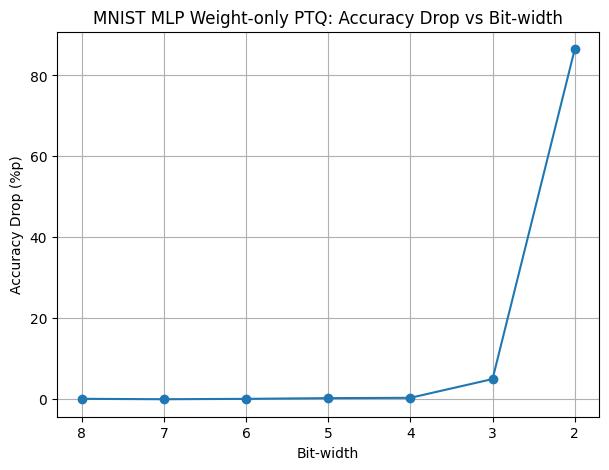

In [15]:
plot_df = accuracy_df.sort_values("bit", ascending=False)

plt.figure(figsize=(7, 5))
plt.plot(
    plot_df["bit"],
    plot_df["accuracy_drop"],
    marker="o",
)
plt.gca().invert_xaxis()
plt.xlabel("Bit-width")
plt.ylabel("Accuracy Drop (%p)")
plt.title("MNIST MLP Weight-only PTQ: Accuracy Drop vs Bit-width")
plt.grid(True)
plt.show()

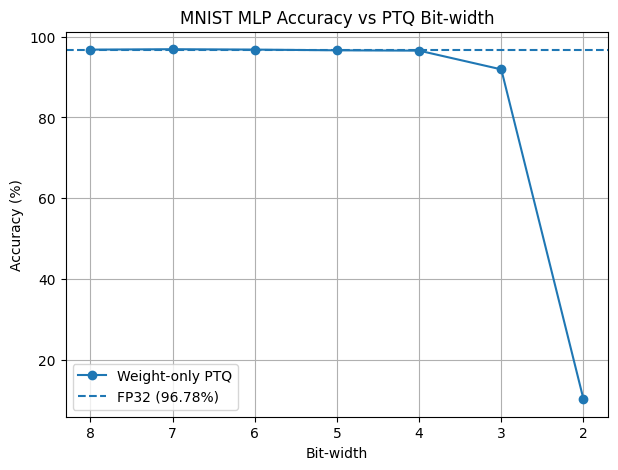

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(
    plot_df["bit"],
    plot_df["ptq_accuracy"],
    marker="o",
    label="Weight-only PTQ",
)

plt.axhline(
    fp32_acc,
    linestyle="--",
    label=f"FP32 ({fp32_acc:.2f}%)",
)

plt.gca().invert_xaxis()
plt.xlabel("Bit-width")
plt.ylabel("Accuracy (%)")
plt.title("MNIST MLP Accuracy vs PTQ Bit-width")
plt.legend()
plt.grid(True)
plt.show()

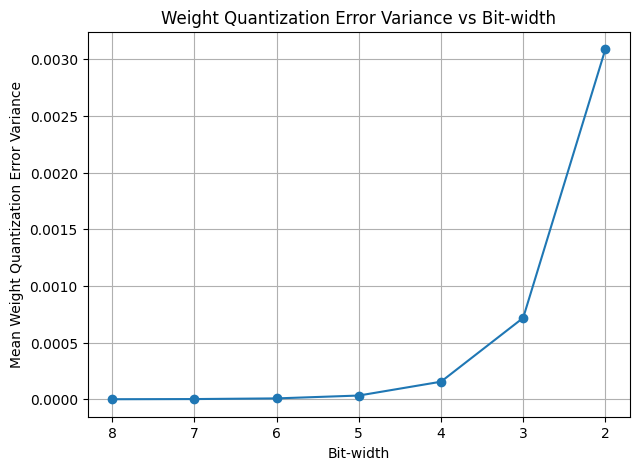

In [17]:
plot_layer_df = layer_summary_df.sort_values("bit", ascending=False)

plt.figure(figsize=(7, 5))
plt.plot(
    plot_layer_df["bit"],
    plot_layer_df["mean_weight_error_variance"],
    marker="o",
)

plt.gca().invert_xaxis()
plt.xlabel("Bit-width")
plt.ylabel("Mean Weight Quantization Error Variance")
plt.title("Weight Quantization Error Variance vs Bit-width")
plt.grid(True)
plt.show()

In [18]:
final_summary_df = accuracy_df.merge(
    layer_summary_df,
    on="bit",
    how="left",
)

display(
    final_summary_df[
        [
            "bit",
            "fp32_accuracy",
            "ptq_accuracy",
            "accuracy_drop",
            "mean_weight_error_variance",
            "mean_weight_mse",
            "mean_scale",
        ]
    ].sort_values("bit", ascending=False)
)

,bit,fp32_accuracy,ptq_accuracy,accuracy_drop,mean_weight_error_variance,mean_weight_mse,mean_scale
0,8,96.78,96.79,-0.01,4.641864e-07,4.642069e-07,0.002296
1,7,96.78,96.89,-0.11,1.885370e-06,1.885383e-06,0.004629
2,6,96.78,96.80,-0.02,7.734412e-06,7.735001e-06,0.009407
3,5,96.78,96.62,0.16,3.290330e-05,3.290478e-05,0.019442
4,4,96.78,96.54,0.24,1.550030e-04,1.550167e-04,0.041662
5,3,96.78,91.90,4.88,7.182068e-04,7.186931e-04,0.097210
6,2,96.78,10.28,86.50,3.088525e-03,3.089054e-03,0.291631


In [19]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()

    preds = []
    labels = []

    for x, y in loader:
        x = x.to(device)

        logits = model(x)
        pred = logits.argmax(dim=1).cpu()

        preds.append(pred)
        labels.append(y.cpu())

    return torch.cat(preds), torch.cat(labels)


fp32_preds, labels = collect_predictions(
    model=model_fp,
    loader=test_loader,
    device=device,
)

prediction_change_rows = []

for bit, model_q in quantized_models.items():
    q_preds, _ = collect_predictions(
        model=model_q,
        loader=test_loader,
        device=device,
    )

    changed = (q_preds != fp32_preds)
    changed_count = changed.sum().item()
    changed_ratio = changed_count / len(labels) * 100

    prediction_change_rows.append({
        "bit": bit,
        "changed_count_vs_fp32": changed_count,
        "changed_ratio_vs_fp32": changed_ratio,
    })

prediction_change_df = pd.DataFrame(prediction_change_rows)
prediction_change_df = prediction_change_df.sort_values("bit", ascending=False)

display(prediction_change_df)

,bit,changed_count_vs_fp32,changed_ratio_vs_fp32
0,8,2,0.02
1,7,12,0.12
2,6,26,0.26
3,5,53,0.53
4,4,122,1.22
5,3,653,6.53
6,2,8962,89.62


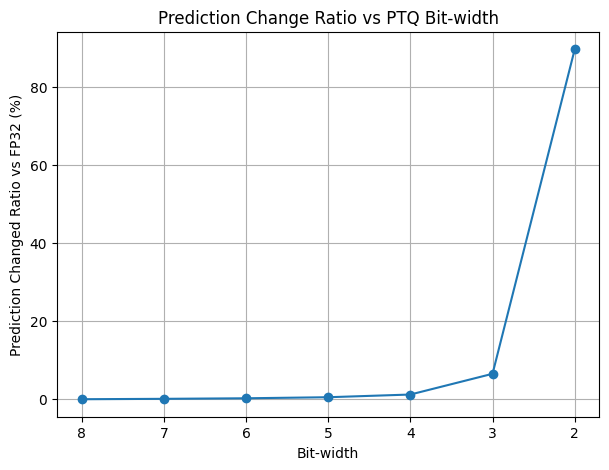

In [20]:
plt.figure(figsize=(7, 5))
plt.plot(
    prediction_change_df["bit"],
    prediction_change_df["changed_ratio_vs_fp32"],
    marker="o",
)

plt.gca().invert_xaxis()
plt.xlabel("Bit-width")
plt.ylabel("Prediction Changed Ratio vs FP32 (%)")
plt.title("Prediction Change Ratio vs PTQ Bit-width")
plt.grid(True)
plt.show()